In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.lines as mlines
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
def read_gsheet_csv(file_id: str, gid: str) -> pd.DataFrame:
    url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv&gid={gid}"
    return pd.read_csv(url)

file_id = "1samWtY_U1Ko2CsiKoa5y8wJ83xvwuajy"

figure_2_country_wos_scopus = read_gsheet_csv(file_id, "685893675")

In [3]:
import pandas as pd
import networkx as nx

df = figure_2_country_wos_scopus  # tu df con columnas: from, to, SR, year

# (opcional pero recomendado) evitar doble conteo si hubiera filas repetidas
df = df.drop_duplicates(subset=["from", "to", "SR", "year"])

# Peso = número de SR (documentos) distintos por par de países
edges_weighted = (
    df.groupby(["from", "to"], as_index=False)
      .agg(Weight=("SR", "nunique"))     # o ("SR","size") si quieres contar filas
)

figure_2_country_wos_scopus_1 = nx.from_pandas_edgelist(
    edges_weighted,
    source="from",
    target="to",
    edge_attr="Weight",
    create_using=nx.Graph()             # o nx.DiGraph() si la dirección importa
)


In [4]:
# Calcular el grado de cada nodo
degree_dict = dict(figure_2_country_wos_scopus_1.degree())

# Detección de comunidades usando Louvain
communities = community_louvain.best_partition(figure_2_country_wos_scopus_1, random_state=0)

# Contar la cantidad de nodos en cada comunidad
community_sizes = pd.Series(communities).value_counts()

# Ordenar de mayor a menor y asignar nuevos índices (0 para la más grande, 1 para la segunda, etc.)
sorted_communities = community_sizes.index.tolist()
community_mapping = {old_comm: new_index+1 for new_index, old_comm in enumerate(sorted_communities)}

# Reasignar las comunidades en el grafo
updated_communities = {node: community_mapping[comm] for node, comm in communities.items()}

# Agregar atributos al grafo
nx.set_node_attributes(figure_2_country_wos_scopus_1, degree_dict, "degree")
nx.set_node_attributes(figure_2_country_wos_scopus_1, updated_communities, "community")

# Figure 3a - Country Collaboration

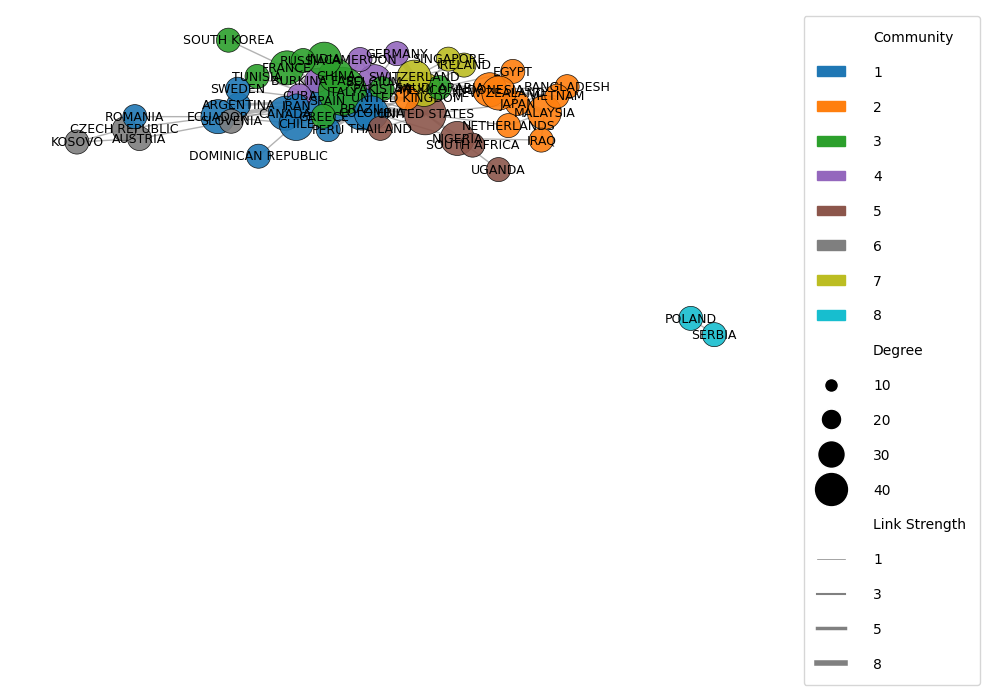

In [5]:
from matplotlib.legend_handler import HandlerTuple
G = figure_2_country_wos_scopus_1


# 2. Calcular la posición de cada nodo (layout)
pos = nx.spring_layout(G)

# 3. Obtener la comunidad y el grado de cada nodo
#    (Asegúrate de que cada nodo tenga el atributo "community" en el GEXF)
node_communities = nx.get_node_attributes(G, "community")
node_degrees = degree_dict  # Si quieres usar grados ponderados usa: G.degree(weight="weight")

# 5. Asignar color y tamaño a cada nodo
#    (Puedes usar un escalado continuo o discreto para el tamaño, según tus preferencias)
def map_degree_to_size(d):
    """Mapea grados a tamaños de nodo. Ajusta los umbrales y valores a tus datos."""
    if d < 5:
        return 300
    elif d < 10:
        return 600
    elif d < 15:
        return 900
    else:
        return 1200


# 6. Obtener el grosor de cada arista a partir de su atributo "weight" (fuerza de enlace)
#    (asumiendo que en tu GEXF el atributo se llame "weight")
node_sizes = []

for n in G.nodes():
    d_value = node_degrees.get(n, 0)
    node_sizes.append(map_degree_to_size(d_value))


edge_widths = []
for (u,v) in G.edges():
    w = G[u][v].get("Weight")
    edge_widths.append(w)

# for u, v, data in G.edges(data=True):
#      data["weight"] = data.pop("Weight")  # Elimina "Weight" y lo reasigna como "weight"

communities_set = sorted(set(nx.get_node_attributes(G, 'community').values()))
color_map = plt.get_cmap('tab10', len(communities_set))
node_colors = {n: color_map(communities_set.index(G.nodes[n]['community'])) for n in G.nodes}

for node, color in node_colors.items():
    r, g, b, a = [int(color[i] * 255) for i in range(3)] + [color[3]]  # a ya está en 0-1

    G.nodes[node]['viz'] = {
        "color": {"r": r, "g": g, "b": b, "a": a}  # a ya está en el rango correcto
    }

node_colors = [color_map(communities_set.index(G.nodes[n]['community'])) for n in G.nodes]


# 7. Dibujar los nodos, aristas y etiquetas
plt.figure(figsize=(10, 6))

# Dibujar nodos, aristas y etiquetas
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    linewidths=0.5,
    edgecolors="black"
)
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.6,
    edge_color="gray"
)
nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_color="black",
)

# Crear leyenda de comunidades
# Leyenda de comunidades (solo número)
community_legend = [
    Patch(color=color_map(communities_set.index(c)), label=f"{c}")
    for c in communities_set
]

# Leyenda de grados (solo intervalo)
degree_legend = [
    Line2D([0], [0], marker='o', color='w', label='10',
           markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='20',
           markerfacecolor='black', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='30',
           markerfacecolor='black', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='40',
           markerfacecolor='black', markersize=25)
]

unique_weights = sorted(set(int(w) for _,_,w in G.edges(data="Weight") if w is not None))

if len(unique_weights) >= 4:
    selected_weights = [
        unique_weights[0],
        unique_weights[len(unique_weights)//3],
        unique_weights[2*len(unique_weights)//3],
        unique_weights[-1]
    ]
else:
    selected_weights = unique_weights

def map_weight_to_width(w):
    return w * 0.5

# 4. Crear la leyenda con pesos reales
linkstrength_legend = [
    Line2D([0], [0], color='gray', lw=map_weight_to_width(w), label=f"{int(w)}")
    for w in selected_weights
]

title_community = Line2D([], [], color='none', label="Community")
title_degree = Line2D([], [], color='none', label="Degree")
title_linkstrength = Line2D([], [], color='none', label="Link Strength")


community_legend = [title_community] + community_legend
degree_legend = [title_degree] + degree_legend
linkstrength_legend = [title_linkstrength] + linkstrength_legend

# Mostrar la leyenda con títulos
plt.legend(
    handles=(community_legend + degree_legend + linkstrength_legend),
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    labelspacing=1.5,      # Espacio vertical entre líneas
    handletextpad=2,       # Espacio entre el marcador y el texto
    borderpad=1            # Espacio del borde de la leyenda con su contenido
)


plt.axis("off")
plt.tight_layout()
plt.savefig("figura_2c.svg", format='svg')

gexf_path = "paises_collaboration_graph_louvain.gexf"
nx.write_gexf(G, gexf_path)
plt.show()

# Figure 2b Clusters

   community   n  x_axis
7          8   2       0
6          7   4       1
5          6   4       2
4          5   5       3
3          4   5       4
2          3  10       5
1          2  10       6
0          1  12       7


<Figure size 640x480 with 0 Axes>

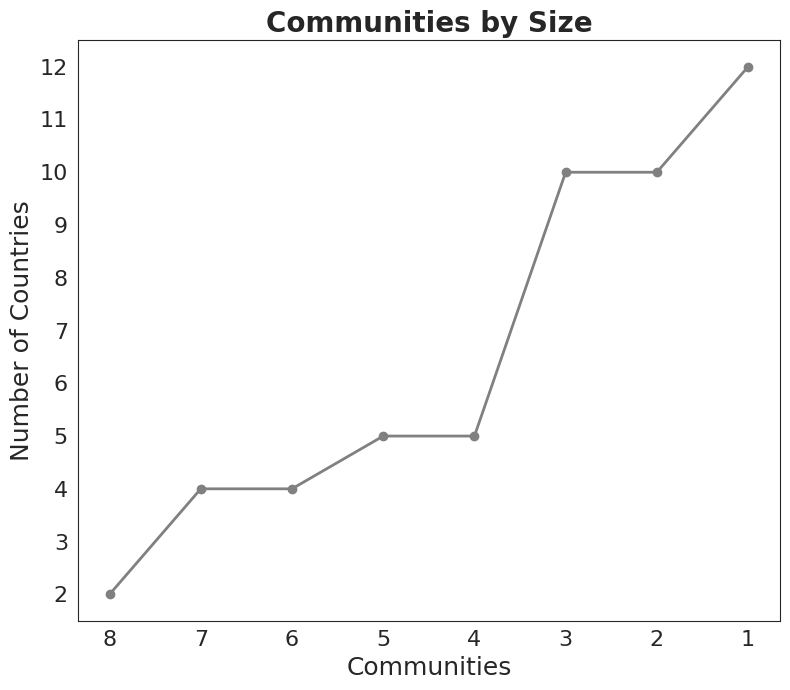

In [6]:
# Crear DataFrame con la nueva numeración de comunidades
nodes_df = pd.DataFrame.from_dict(dict(figure_2_country_wos_scopus_1.nodes(data=True)), orient='index')
nodes_df['node'] = nodes_df.index
nodes_df.reset_index(drop=True, inplace=True)
nodes_df['community'] = nodes_df['community'].astype(int)

# Contar comunidades con la numeración corregida
community_counts = nodes_df['community'].value_counts().reset_index()
community_counts.columns = ['community', 'n']
community_counts = community_counts.sort_values('community', ascending=False,)


# Configurar estilo de plot
community_counts['x_axis'] = range(len(community_counts))

sns.set_style("white")
sns.despine()  # Elimina bordes superiores y derechos

plt.figure(figsize=(8, 7))

# Gráfico de línea con puntos
plt.plot(
    community_counts['x_axis'],
    community_counts['n'],
    marker='o',
    linestyle='-',
    color='gray',
    linewidth=2,
    markersize=6
)

# Títulos y etiquetas
plt.title("Communities by Size", fontsize=20, weight='bold')
plt.xlabel("Communities", fontsize=18)
plt.ylabel("Number of Countries", fontsize=18)

# Etiquetas del eje x
plt.xticks(community_counts['x_axis'], community_counts['community'], fontsize=16)

# Evitar decimales en el eje Y
max_y = community_counts['n'].max()
min_y = community_counts['n'].min()
plt.yticks(range(min_y, max_y + 1), fontsize=16)


# Layout y guardado
plt.tight_layout()

# Guardar como SVG (opcional)
plt.savefig('figura_2b.svg', format='svg')

# Mostrar la tabla de comunidades para referencia
print(community_counts)

plt.show()

# Figure 3c Longitudinal

In [7]:
yearStart = 2006
yearEnd = 2025

figure_2c_edges = (
    figure_2_country_wos_scopus[figure_2_country_wos_scopus['from'] != figure_2_country_wos_scopus['to']]
    .groupby('year')
    .size()
    .reset_index(name='n')
    .query('year >= @yearStart and year <= @yearEnd')
    .assign(percentage=lambda x: x['n'] / x['n'].max())
    [['year', 'percentage']]
    .rename(columns={'year': 'year'})
)
df_valid = figure_2_country_wos_scopus[figure_2_country_wos_scopus['from'] != figure_2_country_wos_scopus['to']].reset_index(drop=True)


unique_countries = pd.concat([
    figure_2_country_wos_scopus['from'],
    figure_2_country_wos_scopus['to']
]).unique()

country_to_id = {country: idx for idx, country in enumerate(sorted(unique_countries), start=1)}


def create_nodes_dataframe():
    # Filtrar donde from != to
    filtered_df = figure_2_country_wos_scopus[figure_2_country_wos_scopus['from'] != figure_2_country_wos_scopus['to']]
    # Crear un grafo dirigido
    G = nx.from_pandas_edgelist(filtered_df, 'from', 'to', create_using=nx.DiGraph())
    # Obtener datos de aristas
    edges_from = filtered_df[['from', 'year']].rename(columns={'from': 'CO', 'year': 'year'})
    # Obtener datos de aristas (destino)
    edges_to = figure_2_country_wos_scopus[['to', 'year']].rename(columns={'to': 'CO', 'year': 'year'})
    # Combinar ambos conjuntos de datos
    combined_edges = pd.concat([edges_from, edges_to])
    # Eliminar duplicados
    unique_edges = combined_edges.drop_duplicates()
    # Agrupar por país y obtener el año mínimo para cada país
    min_year_by_country = unique_edges.groupby('CO')['year'].min().reset_index()
    # Seleccionar solo la columna de año
    years_df = min_year_by_country[['year']]
    # Contar por año
    count_by_year = years_df.groupby('year').size().reset_index(name='n')
    # Filtrar por rango de años
    filtered_by_year = count_by_year[(count_by_year['year'] >= yearStart) &
                                 (count_by_year['year'] <= yearEnd)].copy()
    # Calcular porcentaje
    filtered_by_year['percentage'] = filtered_by_year['n'] / filtered_by_year['n'].max()
    # Seleccionar columnas finales
    figure_2c_nodes = filtered_by_year[['year', 'n', 'percentage']]
    return figure_2c_nodes


figure_2c_nodes = create_nodes_dataframe()



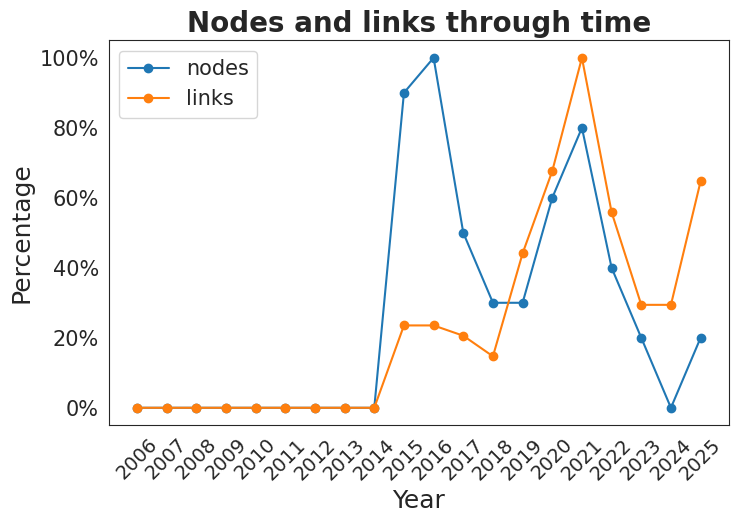

In [8]:
# Combine nodes and edges DataFrames
figure_2c = pd.concat([
    figure_2c_nodes.assign(type='nodes', year=figure_2c_nodes['year'].astype(int)),
    figure_2c_edges.assign(type='links', year=figure_2c_edges['year'].astype(int))
])

# Create the plot
plt.figure(figsize=(8, 5))

years = pd.Series(range(yearStart, yearEnd + 1), name='year')
complete_data = []

for type_name in ['nodes', 'links']:
    # Filtrar los datos de ese tipo
    data = figure_2c[figure_2c['type'] == type_name][['year', 'percentage']]

    # Merge con todos los años
    merged = pd.merge(years, data, on='year', how='left')
    merged['percentage'] = merged['percentage'].fillna(0)
    merged['type'] = type_name

    complete_data.append(merged)

# Combinar los datos completos
figure_2c_filled = pd.concat(complete_data)


# Plot nodes and links
for type_name in ['nodes', 'links']:
    data = figure_2c_filled[figure_2c_filled['type'] == type_name]
    plt.plot(data['year'], data['percentage'],
             marker='o',
             label=type_name,
             linestyle='-')

# Customize the plot
plt.title("Nodes and links through time", fontsize=20, weight='bold')
plt.ylabel("Percentage", fontsize=18)
plt.xlabel("Year", fontsize=18)

# Set y-axis to percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.yticks(fontsize=15)

# Customize x-axis
plt.xticks(range(yearStart, yearEnd + 1), rotation=45, fontsize=14)

# Customize appearance
plt.gca().set_facecolor('white')

# Add legend
plt.legend(title=None, fontsize=15, loc="upper left")

# Adjust layout and add grid
#plt.grid(True, linestyle="--", alpha=0.5)

# Save the plot
plt.savefig("figura_2a.svg", format='svg')

# Optional: display the plot (comment out if not in interactive environment)
plt.show()